# PromoFlow: A Data-Driven Decision Support MVP for Promotional Demand Forecasting and Inventory Risk Analysis
## M3DM: Individual Project (DATDRD05-T08 - Data Science Tools and Techniques) 

---

## CRISP-DM Phase 1: Business Understanding

## Introduction

This project was developed as part of the Minor Data-Driven Decision Making (M3DM) individual assignment. The objective of the assignment is to explore data-driven technologies, experiment with analytical techniques, and develop a Minimum Viable Product (MVP) inspired by concepts learned throughout the exploration journey.

The project focuses on promotional demand planning within the pharmaceutical supply chain. The idea is inspired by a real-world business scenario based on a large European animal healthcare company operating within the over-the-counter (OTC) pharmaceutical market.

Rather than building a production-ready forecasting system, the goal is to develop a proof-of-concept decision-support tool that demonstrates how forecasting, promotional planning, and inventory risk assessment can be combined into a single analytical application.

---

## Business Context

In the pharmaceutical industry, products are commonly sold to wholesalers who subsequently distribute products to pharmacies, retail chains, veterinary practices, and other downstream customers.

Sales occur throughout the year; however, significant demand increases often occur during promotional periods. During these campaigns, wholesalers may receive commercial incentives that encourage larger purchases. These incentives can take various forms, including promotional discounts, bonus quantities, coupon programmes, or volume-based purchasing agreements.

Promotional campaigns create additional complexity for supply chain planning because demand can increase substantially compared to normal purchasing behaviour. If promotional demand is underestimated, stock shortages may occur. Conversely, overestimating demand may lead to excess inventory, increased holding costs, and reduced operational efficiency.

One of the key challenges highlighted within the case is that promotional planning often relies heavily on manual judgement, historical experience, and communication between sales and supply chain teams. Promotional information may also become available relatively late in the planning cycle, reducing visibility and making proactive planning difficult.

---

## Problem Statement

Supply chain planners require better visibility into potential promotional demand and inventory risks before promotional campaigns are executed.

Without structured analytical support, organisations may experience:

- Demand forecasting inaccuracies.
- Inventory shortages during promotional periods.
- Excess inventory following promotions.
- Increased operational pressure on planning teams.
- Limited ability to evaluate alternative promotional scenarios.

This project explores how historical sales data and promotional information can be used together to support more informed decision-making.

---

## Project Objective

The primary objective of PromoFlow AI is to develop a decision-support MVP capable of assisting planners in evaluating future demand and potential inventory risks under different promotional scenarios.

The system aims to:

1. Analyse historical pharmaceutical demand patterns.
2. Forecast future baseline demand.
3. Simulate promotional demand scenarios.
4. Estimate inventory risk under different demand assumptions.
5. Provide an interactive interface that supports planning decisions.

The project is intended as an exploratory analytical tool and proof-of-concept MVP rather than a production forecasting solution.

---

## CRISP-DM Phase 1: Business Understanding
### Dataset 1: Pharmaceutical Sales Data

This dataset contains monthly pharmaceutical sales information across multiple therapeutic categories from 2014 to 2019.

Purpose:
- Historical demand analysis
- Trend analysis
- Seasonality analysis
- Demand forecasting

### Dataset 2: Retail Pricing and Demand Dataset

This dataset contains information relating to discounts, promotional activities, inventory levels, stock availability, and demand outcomes.

Purpose:
- Promotion analysis
- Scenario planning
- Inventory risk exploration
- Promotional demand assumptions

The datasets are not directly related at a transaction level. Instead, they are used together to support different analytical components of the MVP.

---

## 7. Scope and Limitations

Several limitations should be acknowledged.

First, publicly available animal pharmaceutical promotional datasets are not available. Therefore, promotional behaviour cannot be validated against real wholesaler campaign data.

Second, the MVP does not attempt to predict actual promotional outcomes. Instead, it provides a framework for exploring and simulating promotional demand scenarios.

Finally, the project should be viewed as a decision-support prototype designed for learning, experimentation, and demonstration purposes.

---

## 8. Expected MVP Features

The final MVP is expected to include:

- Historical demand analytics dashboard.
- Baseline demand forecasting functionality.
- Promotional scenario simulator.
- Inventory risk assessment module.
- Interactive Streamlit interface.

These features collectively demonstrate how data-driven techniques can support promotional demand planning within a supply chain context.


In [1]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# CRISP-DM Phase 2: Data Understanding

## 1. Objective

The purpose of this phase is to understand the available datasets, evaluate their suitability for the business problem, identify potential limitations, and determine how they can contribute to the PromoFlow AI MVP.

The project uses two separate datasets.

The first dataset contains historical pharmaceutical sales information and will be used for demand analysis and forecasting.

The second dataset contains promotional and pricing-related information and will be used to explore promotional behaviour, inventory indicators, and scenario planning assumptions.

The datasets serve complementary purposes rather than being merged directly at a transaction level.

The goal of this phase is to:

- Understand the structure of both datasets.
- Assess data quality.
- Identify relevant variables.
- Explore trends and patterns.
- Determine how the datasets support the project objectives.

In [4]:

# LOADING DATASETS

sales_df = pd.read_csv("/Users/isheeta/Desktop/PromoFlow_m3dmproject_individual/salesmonthly.csv")

promo_df = pd.read_csv("/Users/isheeta/Desktop/PromoFlow_m3dmproject_individual/retail_pricing_demand_100k.csv")

print("Sales Dataset Shape:", sales_df.shape)
print("Promotion Dataset Shape:", promo_df.shape)

Sales Dataset Shape: (70, 9)
Promotion Dataset Shape: (172800, 17)


## 2. Initial Dataset Assessment

### Pharmaceutical Sales Dataset

The pharmaceutical dataset contains monthly sales information across multiple therapeutic drug categories between 2014 and 2019. The dataset provides a relatively small but highly relevant time-series suitable for trend analysis, seasonality detection, and demand forecasting.

Strengths:

- Real pharmaceutical sales data.
- Multi-year historical observations.
- Monthly granularity appropriate for supply chain planning.
- Multiple product categories.

Limitations:

- No inventory information.
- No promotional campaign information.
- No wholesaler-level data.
- Limited number of observations for advanced forecasting models.

### Promotion and Pricing Dataset

The promotion dataset contains information related to pricing, discounts, promotional activities, inventory levels, stock availability, and demand outcomes.

Strengths:

- Large number of observations.
- Contains promotion-related variables.
- Contains inventory indicators.
- Contains stockout information.
- Suitable for promotional scenario analysis.

Limitations:

- Not pharmaceutical-specific.
- Cannot be directly linked to the pharmaceutical dataset at transaction level.

Together, both datasets provide complementary perspectives that support the development of a promotional demand planning MVP.

In [5]:
# PHARMACEUTICAL DATA OVERVIEW

sales_df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


In [6]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   datum   70 non-null     object 
 1   M01AB   70 non-null     float64
 2   M01AE   70 non-null     float64
 3   N02BA   70 non-null     float64
 4   N02BE   70 non-null     float64
 5   N05B    70 non-null     float64
 6   N05C    70 non-null     float64
 7   R03     70 non-null     float64
 8   R06     70 non-null     float64
dtypes: float64(8), object(1)
memory usage: 5.1+ KB


In [7]:
sales_df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,149.992000,116.514286,115.020843,892.542071,262.118571,17.842857,167.675000,86.662571
std,31.485325,27.889336,31.245899,338.843908,85.060930,8.481242,81.767979,45.859336
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,137.490000,103.518250,94.375000,648.187500,223.750000,12.000000,112.000000,49.875000
50%,154.635000,114.840000,117.225000,865.824500,250.300000,18.000000,160.000000,74.100000
75%,169.000000,128.359750,133.837500,1061.580000,293.650000,23.000000,218.250000,119.807500
max,211.130000,222.351000,191.600000,1856.815000,492.000000,50.000000,386.000000,213.040000


## 3. Pharmaceutical Dataset Analysis

### Data Quality Assessment

The pharmaceutical dataset contains 70 monthly observations across eight therapeutic product categories.

Key findings:

- No missing values were identified.
- All sales variables are stored as numerical values.
- The date variable is currently stored as text and will be converted to a datetime format during data preparation.
- The dataset covers approximately six years of historical demand data.

### Initial Business Insights

Preliminary statistical analysis indicates that demand differs substantially between product categories. Certain therapeutic categories exhibit significantly higher average sales volumes than others, suggesting that inventory requirements and forecasting behaviour may vary across products.

These findings support the need for category-level demand analysis rather than relying solely on aggregate demand measures.

In [8]:
# CONVERTING THE DATE COLUMN

sales_df["datum"] = pd.to_datetime(sales_df["datum"])

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   70 non-null     datetime64[ns]
 1   M01AB   70 non-null     float64       
 2   M01AE   70 non-null     float64       
 3   N02BA   70 non-null     float64       
 4   N02BE   70 non-null     float64       
 5   N05B    70 non-null     float64       
 6   N05C    70 non-null     float64       
 7   R03     70 non-null     float64       
 8   R06     70 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 5.1 KB


In [9]:

# CHECKING THE DATE RANGE

print("Start Date:", sales_df["datum"].min())
print("End Date:", sales_df["datum"].max())

Start Date: 2014-01-31 00:00:00
End Date: 2019-10-31 00:00:00


In [10]:
# TOTAL SALES BY CATEGORY

category_totals = sales_df.drop("datum", axis=1).sum()

category_totals.sort_values(ascending=False)

N02BE    62477.945
N05B     18348.300
R03      11737.250
M01AB    10499.440
M01AE     8156.000
N02BA     8051.459
R06       6066.380
N05C      1249.000
dtype: float64

## 4. Exploratory Data Analysis

### Objective

Before developing forecasting and scenario-planning functionality, exploratory data analysis was conducted to better understand historical demand behaviour across product categories.

The purpose of this analysis is to:

- Identify major product categories.
- Explore demand trends over time.
- Detect seasonality patterns.
- Understand variability between therapeutic groups.
- Generate insights relevant to supply chain planning.

Understanding historical demand behaviour is critical because forecasting quality depends heavily on the characteristics of the underlying demand signal.

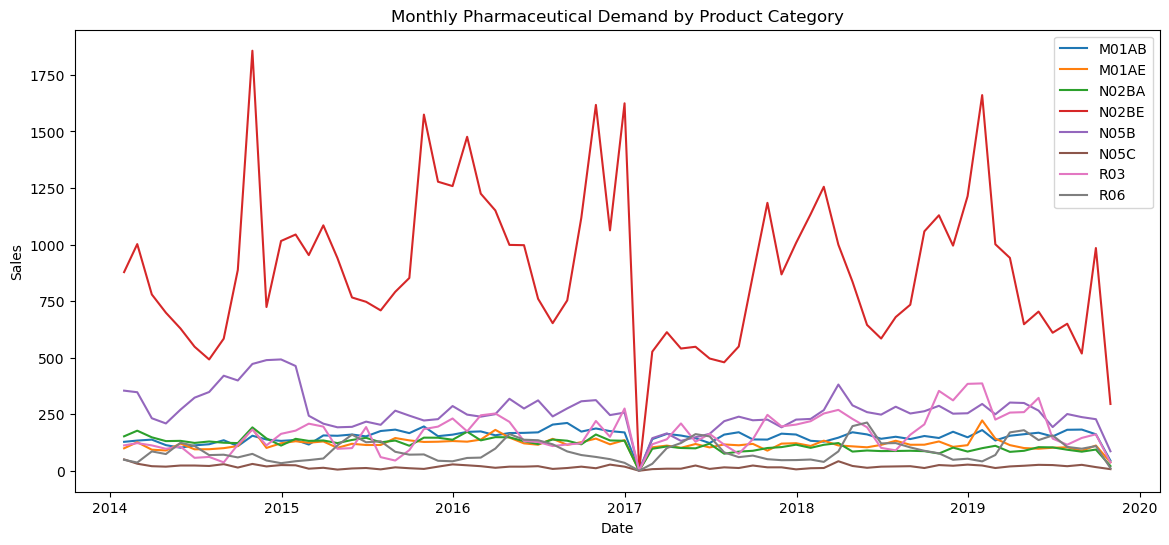

In [11]:

# DEMAND TRENDS BY PRODUCT CATEGORY

plt.figure(figsize=(14,6))

for col in sales_df.columns[1:]:
    plt.plot(sales_df["datum"], sales_df[col], label=col)

plt.title("Monthly Pharmaceutical Demand by Product Category")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

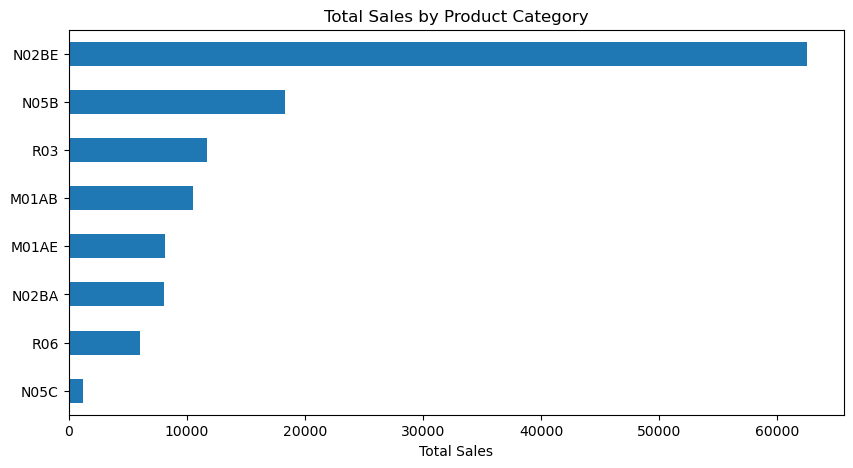

In [12]:
# TOTAL SALES BY CATEGORY

category_totals.sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.show()

### Exploratory Analysis Findings

Several important demand planning insights emerged from the exploratory analysis.

First, demand is highly concentrated within a small number of therapeutic categories. N02BE contributes substantially more sales volume than any other category and therefore represents a critical planning category from an inventory management perspective.

Second, demand patterns exhibit significant fluctuations over time. These variations suggest that forecasting methods capable of capturing trend and seasonality may provide value for planning activities.

Third, product categories display distinct demand characteristics, indicating that category-level forecasting may be more appropriate than relying exclusively on aggregate demand measures.

Finally, an unusual decline is visible across multiple categories during early 2017. Due to the absence of contextual business information, this observation is treated as an anomalous event and retained within the dataset for transparency.

In [13]:

# CREATE TOTAL PORTFOLIO DEMAND

sales_df["Total_Demand"] = sales_df.drop(
    columns=["datum"]
).sum(axis=1)

sales_df[["datum", "Total_Demand"]].head()

,datum,Total_Demand
0,2014-01-31,1821.110
1,2014-02-28,1974.470
2,2014-03-31,1606.720
3,2014-04-30,1429.675
4,2014-05-31,1506.303


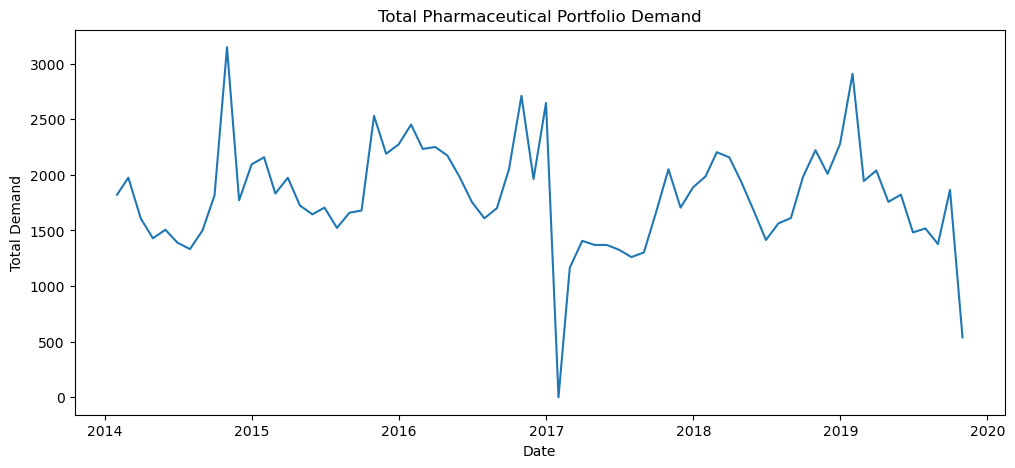

In [14]:
# PLOT TOTAL PORTFOLIO DEMAND


plt.figure(figsize=(12,5))

plt.plot(
    sales_df["datum"],
    sales_df["Total_Demand"]
)

plt.title("Total Pharmaceutical Portfolio Demand")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.show()

In [15]:

# PROMOTION DATASET OVERVIEW

promo_df.head()

,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,NaN,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,312,0,116.07
3,2026-01-04,P1001,Shoes,Nike,AU,web,Winter,173.55,164.87,-5.0,5,Member Offer,13,2143.31,227,0,116.07
4,2026-01-05,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,247,0,116.07


In [16]:
promo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172800 entries, 0 to 172799
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   date              172800 non-null  object 
 1   product_id        172800 non-null  object 
 2   category          172800 non-null  object 
 3   brand             172800 non-null  object 
 4   region            172800 non-null  object 
 5   channel           172800 non-null  object 
 6   season            172800 non-null  object 
 7   base_price        172800 non-null  float64
 8   current_price     172800 non-null  float64
 9   price_change_pct  172800 non-null  float64
 10  discount_pct      172800 non-null  int64  
 11  promotion_type    72645 non-null   object 
 12  units_sold        172800 non-null  int64  
 13  revenue           172800 non-null  float64
 14  inventory_level   172800 non-null  int64  
 15  stockout_flag     172800 non-null  int64  
 16  demand_index      17

In [17]:
promo_df.describe()

,base_price,current_price,price_change_pct,discount_pct,units_sold,revenue,inventory_level,stockout_flag,demand_index
count,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000,172800.000000
mean,221.370656,197.828360,-10.657955,10.657957,14.120735,2757.295723,265.278299,0.001325,117.443514
std,125.659903,118.293731,14.559533,14.559510,8.344558,2410.520529,85.315024,0.036380,33.590506
min,8.550000,4.280000,-50.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,112.302500,97.160000,-20.000000,0.000000,7.000000,856.560000,208.000000,0.000000,95.240000
50%,217.325000,188.960000,0.000000,0.000000,13.000000,2023.890000,265.000000,0.000000,113.640000
75%,326.277500,287.960000,0.000000,20.000000,20.000000,4064.280000,323.000000,0.000000,136.090000
max,449.740000,449.740000,0.000000,50.000000,69.000000,18431.970000,646.000000,1.000000,365.080000


In [18]:

# PROMOTION DISTRIBUTION

promo_df["discount_pct"].value_counts().sort_index()

discount_pct
0     100155
5       2985
10      9074
15      9032
20     10723
25      6217
30     14456
35      8619
40      8163
50      3376
Name: count, dtype: int64

In [19]:

# PROMOTION TYPES


promo_df["promotion_type"].value_counts(dropna=False)

promotion_type
NaN                    100155
Percentage Discount     30974
Flash Sale              13911
Clearance               10379
Member Offer             8762
Buy One Get One          8619
Name: count, dtype: int64

## Promotion Dataset Initial Assessment

The promotion dataset contains detailed information regarding pricing actions, promotional campaigns, product characteristics, sales performance, and inventory indicators.

Initial inspection reveals a broad range of discount percentages and promotion mechanisms including percentage discounts, flash sales, clearance campaigns, member offers, and buy-one-get-one promotions.

From a supply chain perspective, these variables provide the foundation for analysing how promotional decisions influence sales volume, revenue generation, inventory levels, and stockout risks.

The dataset therefore supports the development of promotion effectiveness analyses and decision-support functionality within the proposed MVP.

In [20]:
# CONVERT DATE COLUMN

promo_df["date"] = pd.to_datetime(promo_df["date"])

print("Start Date:", promo_df["date"].min())
print("End Date:", promo_df["date"].max())

Start Date: 2026-01-01 00:00:00
End Date: 2026-03-31 00:00:00


## Promotion Dataset Time Horizon Assessment

The promotion dataset covers the period from January 2026 to March 2026.

Although the time horizon is shorter than the pharmaceutical sales dataset, it provides detailed observations regarding promotional actions, pricing changes, inventory conditions, and sales outcomes.

This level of operational detail enables the investigation of promotion effectiveness and supports the development of decision-support capabilities for promotional planning.

The dataset is therefore considered suitable for exploratory analysis and MVP demonstration purposes.

In [21]:
# DISCOUNT IMPACT ON SALES

promo_df.groupby("discount_pct")["units_sold"].mean().sort_index()

discount_pct
0     12.560601
5     13.376549
10    13.952942
15    14.848649
20    15.510958
25    16.232910
30    16.929026
35    17.742894
40    18.412103
50    19.612263
Name: units_sold, dtype: float64

## Impact of Discount Levels on Sales Performance

To evaluate the effectiveness of promotional actions, average units sold were analysed across different discount percentages.

The results reveal a clear positive relationship between discount intensity and sales volume. Products sold without discounts achieve the lowest average sales volumes, while progressively larger discounts are associated with higher average units sold.

This observation aligns with established retail and supply chain principles, where price reductions stimulate customer demand.

From a business perspective, discount percentage appears to be a significant explanatory variable influencing sales performance and should therefore be incorporated into future predictive and decision-support models.

However, higher sales volumes do not automatically imply higher profitability. Further analysis should consider the impact of discounts on revenue and inventory performance before recommending specific promotional strategies.

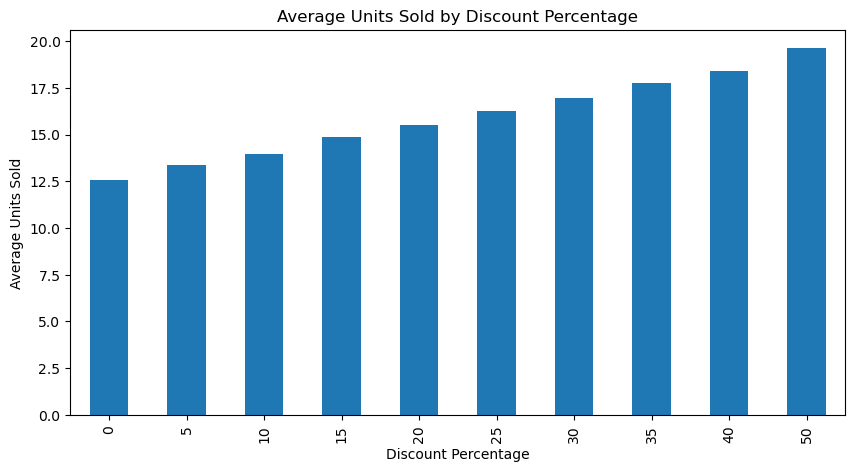

In [22]:
# DISCOUNT VS SALES VISUALIZATION

discount_sales = (
    promo_df.groupby("discount_pct")["units_sold"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,5))

discount_sales.plot(
    kind="bar"
)

plt.title("Average Units Sold by Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Average Units Sold")

plt.show()

## Relationship Between Discount Intensity and Sales Volume

The visualization confirms the positive relationship previously observed during the numerical analysis.

As discount percentages increase, average units sold consistently rise. This suggests that customers are responsive to price reductions and that promotional discounts can effectively stimulate demand.

The relationship appears relatively stable across the available discount levels, indicating that discount percentage may serve as an important explanatory variable within future forecasting and decision-support models.

For supply chain planners, this insight highlights the importance of anticipating increased demand during promotional periods to avoid inventory shortages and service disruptions.

The next stage of analysis investigates whether increased sales volumes generated by discounts also translate into improved revenue performance.

In [23]:
# DISCOUNT IMPACT ON REVENUE

promo_df.groupby("discount_pct")["revenue"].mean().sort_index()

discount_pct
0     2815.858017
5     2843.361662
10    2805.792234
15    2785.713574
20    2770.594745
25    2738.292205
30    2676.820843
35    2588.996103
40    2461.153303
50    2220.544698
Name: revenue, dtype: float64

## Impact of Discount Levels on Revenue Performance

A second analysis examined the relationship between discount percentages and average revenue.

Unlike sales volume, revenue demonstrates a declining trend as discount percentages increase.

Although larger discounts generate higher sales volumes, the reduction in selling price appears to outweigh the additional units sold, resulting in lower average revenue.

This finding highlights a critical managerial trade-off between demand stimulation and financial performance.

From a supply chain and commercial planning perspective, promotional strategies should therefore balance sales growth objectives against revenue and profitability considerations.

The results suggest that moderate discount levels may provide a more favourable balance between demand generation and financial outcomes than aggressive discounting strategies.

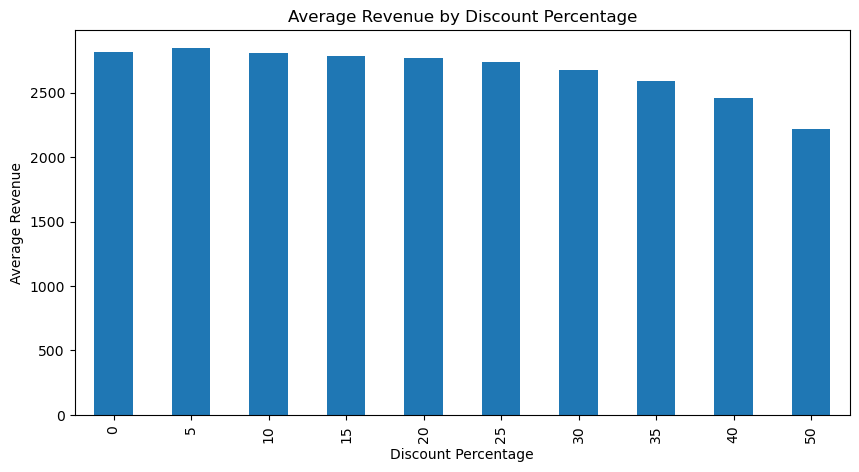

In [24]:
# REVENUE BY DISCOUNT LEVEL

discount_revenue = (
    promo_df.groupby("discount_pct")["revenue"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10,5))

discount_revenue.plot(
    kind="bar"
)

plt.title("Average Revenue by Discount Percentage")
plt.xlabel("Discount Percentage")
plt.ylabel("Average Revenue")

plt.show()

## Revenue Impact of Promotional Discounts

The revenue analysis reveals an inverse relationship between discount intensity and average revenue.

While previous results demonstrated that higher discounts increase sales volumes, the current findings indicate that revenue declines as discounts become larger.

This suggests that the additional sales generated by promotional activities are insufficient to fully compensate for the reduced selling price.

From a managerial perspective, excessive discounting may therefore create situations where demand increases but financial performance deteriorates.

These findings highlight the importance of balancing commercial objectives with supply chain efficiency and profitability targets when designing promotional strategies.

Consequently, promotion planning should focus on identifying discount levels that maximise overall business value rather than solely maximising sales volume.

In [26]:
# INVENTORY LEVELS DURING DIFFERENT DISCOUNT LEVELS

promo_df.groupby("discount_pct")["inventory_level"].mean().sort_index()

discount_pct
0     266.908162
5     266.780905
10    265.832268
15    264.628543
20    263.937051
25    261.509410
30    262.716588
35    261.408284
40    260.802401
50    258.718898
Name: inventory_level, dtype: float64

## Impact of Promotional Discounts on Inventory Levels

Inventory levels were analysed across different discount percentages to assess the operational impact of promotional activities.

The results indicate a gradual decline in average inventory levels as discount intensity increases.

This observation is consistent with previous findings showing that larger discounts stimulate higher sales volumes. Increased product movement naturally contributes to faster inventory depletion.

Although the magnitude of the inventory reduction is moderate, the trend highlights the importance of coordinating promotional planning with inventory management processes.

Supply chain planners should therefore consider anticipated promotional demand when determining replenishment requirements and inventory policies.

In [27]:
# STOCKOUT RISK BY DISCOUNT LEVEL

promo_df.groupby("discount_pct")["stockout_flag"].mean().sort_index()

discount_pct
0     0.001328
5     0.000335
10    0.000771
15    0.001329
20    0.001212
25    0.001769
30    0.001245
35    0.001508
40    0.001470
50    0.002666
Name: stockout_flag, dtype: float64

## Impact of Promotional Discounts on Stockout Risk

Stockout probabilities were analysed across different discount levels using the stockout indicator variable.

The results show that stockout risk generally increases as discount percentages become larger. The highest discount level (50%) exhibits the greatest stockout probability within the dataset.

Although stockout events remain relatively rare overall, the findings suggest that aggressive promotions may increase operational risk by generating demand levels that exceed available inventory.

Combined with previous results showing higher sales volumes and lower inventory levels under larger discounts, this observation highlights the importance of aligning promotional decisions with inventory planning activities.

Effective promotional strategies should therefore balance demand stimulation objectives against potential service-level disruptions caused by inventory shortages.

In [90]:
mvp_df = promo_df.copy()

mvp_df.head() 

,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,NaN,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,312,0,116.07
3,2026-01-04,P1001,Shoes,Nike,AU,web,Winter,173.55,164.87,-5.0,5,Member Offer,13,2143.31,227,0,116.07
4,2026-01-05,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,247,0,116.07


In [91]:
mvp_df.to_csv("promo_mvp_dataset.csv", index=False)

print("Saved successfully")

Saved successfully


# MVP Development Preparation

In [92]:
mvp_df.shape

(172800, 17)

In [93]:
mvp_df.isnull().sum()

date                     0
product_id               0
category                 0
brand                    0
region                   0
channel                  0
season                   0
base_price               0
current_price            0
price_change_pct         0
discount_pct             0
promotion_type      100155
units_sold               0
revenue                  0
inventory_level          0
stockout_flag            0
demand_index             0
dtype: int64

In [94]:
mvp_df = mvp_df.copy()

mvp_df["promotion_type"] = (
    mvp_df["promotion_type"]
    .fillna("No Promotion")
)

In [95]:
mvp_df.isnull().sum()

date                0
product_id          0
category            0
brand               0
region              0
channel             0
season              0
base_price          0
current_price       0
price_change_pct    0
discount_pct        0
promotion_type      0
units_sold          0
revenue             0
inventory_level     0
stockout_flag       0
demand_index        0
dtype: int64

In [109]:
mvp_df.to_csv(
    "promo_mvp_dataset_clean.csv",
    index=False
)

print("Final MVP dataset saved")

Final MVP dataset saved


# DEVELOPING THE MODEL 

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

model_df = mvp_df.copy()

print(model_df.shape)

(172800, 17)


In [111]:
categorical_cols = [
    "product_id",
    "category",
    "brand",
    "region",
    "channel",
    "promotion_type",
    "season"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

model_df.head()

,date,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,0,6,21,0,1,1,173.55,112.81,-35.0,35,0,15,1692.15,153,0,133.93
1,2026-01-02,0,6,21,0,2,1,173.55,173.55,0.0,0,4,10,1735.50,185,0,89.29
2,2026-01-03,0,6,21,0,0,1,173.55,173.55,0.0,0,4,13,2256.15,312,0,116.07
3,2026-01-04,0,6,21,0,2,1,173.55,164.87,-5.0,5,3,13,2143.31,227,0,116.07
4,2026-01-05,0,6,21,0,0,1,173.55,173.55,0.0,0,4,13,2256.15,247,0,116.07


In [112]:
model_df["date"] = pd.to_datetime(model_df["date"])

model_df["month"] = model_df["date"].dt.month
model_df["day"] = model_df["date"].dt.day

model_df = model_df.drop("date", axis=1)

model_df.head()

,product_id,category,brand,region,channel,season,base_price,current_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index,month,day
0,0,6,21,0,1,1,173.55,112.81,-35.0,35,0,15,1692.15,153,0,133.93,1,1
1,0,6,21,0,2,1,173.55,173.55,0.0,0,4,10,1735.50,185,0,89.29,1,2
2,0,6,21,0,0,1,173.55,173.55,0.0,0,4,13,2256.15,312,0,116.07,1,3
3,0,6,21,0,2,1,173.55,164.87,-5.0,5,3,13,2143.31,227,0,116.07,1,4
4,0,6,21,0,0,1,173.55,173.55,0.0,0,4,13,2256.15,247,0,116.07,1,5


In [113]:
X = model_df.drop(
    [
        "units_sold",
        "revenue",
        "stockout_flag"
    ],
    axis=1
)

y = model_df["units_sold"]

print(X.shape)
print(y.shape)

(172800, 15)
(172800,)


In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(138240, 15)
(34560, 15)


In [115]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [116]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

preds = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 0.23641464120370373
R2: 0.9806951187572477


# MODELS- A COMPARISON

In [117]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("R2:", r2_score(y_test, lr_preds))

Linear Regression
MAE: 5.5628685960964726
R2: 0.33769507918868535


In [118]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, dt_preds))
print("R2:", r2_score(y_test, dt_preds))

Decision Tree
MAE: 0.18125
R2: 0.9610775641900196


In [119]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, dt_preds),
        mean_absolute_error(y_test, preds)
    ],
    "R2": [
        r2_score(y_test, lr_preds),
        r2_score(y_test, dt_preds),
        r2_score(y_test, preds)
    ]
})

results

,Model,MAE,R2
0,Linear Regression,5.562869,0.337695
1,Decision Tree,0.181250,0.961078
2,Random Forest,0.236415,0.980695


# Understanding Modelling for this Project

## Introduction

The Modelling phase represents the fourth stage of the Cross Industry Standard Process for Data Mining (CRISP-DM) methodology and focuses on transforming prepared data into predictive models capable of supporting organisational decision-making (Chapman et al., 2000). Following the completion of the Business Understanding, Data Understanding, and Data Preparation phases, the PromoFlow project proceeds towards the development of a predictive demand forecasting model intended to support promotion planning decisions.

Within retail, pharmaceutical, and animal health supply chains, promotional activities directly influence product demand, inventory consumption, replenishment requirements, service levels, and stockout risk. As a result, organisations increasingly rely on predictive analytics and machine learning techniques to estimate future demand under different commercial scenarios before implementing pricing and promotional decisions (Chopra & Meindl, 2019).

The objective of PromoFlow is therefore not simply to analyse historical promotional performance but to provide a foundation for predictive decision support. Specifically, the project aims to forecast expected sales volumes based on product characteristics, promotional conditions, channel selection, and operational supply chain variables.

This modelling approach aligns closely with concepts introduced in DATDRD05-T07 Introduction to Modelling. Weber (2025) emphasises that organisational decision problems should be translated into formal analytical representations capable of supporting managerial decision-making. Rather than relying exclusively on descriptive reporting, predictive models enable organisations to estimate future outcomes and compare alternative actions before implementation.

Similarly, the approach reflects principles discussed in DATDRD05-T06 Introduction to Data Mining, where Ten Hove (2025) highlights the importance of discovering predictive patterns from historical data and evaluating alternative modelling approaches before selecting a final solution.

---

## Business Problem Translation

The original business problem identified during the Business Understanding phase can be formulated as follows:

**How can promotional decisions be optimised to increase sales while maintaining supply chain performance and reducing operational risk?**

To address this challenge, the business problem was translated into a supervised machine learning problem.

The target variable selected for prediction is:

**Units Sold**

This variable represents realised customer demand and serves as the primary indicator of promotional effectiveness.

The predictor variables include:

* Product ID
* Category
* Brand
* Region
* Channel
* Discount Percentage
* Promotion Type
* Inventory Level
* Stockout Indicator

From a modelling perspective, the objective becomes:

**Predict future sales volumes based on promotional characteristics and operational conditions.**

This formulation creates a direct link between commercial decision-making and quantitative demand forecasting.

---

## Model Selection: Strategy

Industry best practice recommends evaluating multiple candidate algorithms before selecting a final predictive model (Han et al., 2022; James et al., 2021). Consequently, three modelling approaches were selected for comparison:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

These models represent increasing levels of complexity and analytical capability.

The comparison strategy serves two purposes:

1. To identify the most accurate forecasting model.
2. To provide a transparent and academically justified model selection process.

This approach follows both CRISP-DM recommendations and the model comparison principles discussed in DATDRD05-T07 Introduction to Modelling (Weber, 2025).

---

## Model 1: Linear Regression

Linear Regression was selected as a baseline model.

Linear Regression assumes that relationships between independent variables and the target variable can be represented through a linear equation. Because of its simplicity and interpretability, Linear Regression remains one of the most commonly used benchmark models in predictive analytics and machine learning studies (James et al., 2021).

Within promotional planning contexts, Linear Regression assumes that variables such as discount percentage influence demand proportionally.

For example, increasing a discount from 10% to 20% would be expected to produce a similar incremental effect as increasing a discount from 20% to 30%.

However, previous research in retail demand forecasting suggests that customer purchasing behaviour is frequently nonlinear and often influenced by threshold effects, promotional mechanisms, and contextual factors (Han et al., 2022).

Consequently, Linear Regression was included primarily as a benchmark against which more sophisticated algorithms could be evaluated.

---

## Model 2: Decision Tree Regression

Decision Tree Regression was selected because promotional demand frequently exhibits nonlinear behaviour.

Consumers do not always respond proportionally to discounts. A small discount may generate limited demand stimulation, whereas larger discounts may trigger substantially different purchasing behaviour.

Decision Trees are capable of modelling such relationships by recursively partitioning data into decision regions and identifying important threshold values (Han et al., 2022).

Within the context of promotional planning, a Decision Tree may learn patterns such as:

* High discounts combined with high inventory levels lead to strong sales growth.
* Certain promotion types outperform others within specific regions.
* Demand responses vary across sales channels.

An additional advantage of Decision Trees is their interpretability, which supports managerial understanding and decision support.

---

## Model 3: Random Forest Regression

Random Forest Regression was selected as an advanced ensemble learning method.

Random Forest extends Decision Tree methodology by combining multiple trees and aggregating their predictions (Breiman, 2001).

The fundamental rationale behind Random Forest is that individual trees may suffer from instability and overfitting, whereas aggregating many trees produces more robust and generalisable predictions.

Random Forest models have become widely adopted within retail analytics, demand forecasting, pharmaceutical supply chains, and commercial planning environments because they:

* Capture nonlinear relationships.
* Handle mixed categorical and numerical variables.
* Identify complex interactions between predictors.
* Reduce overfitting risk.
* Deliver strong predictive performance on structured business datasets.

These characteristics make Random Forest particularly suitable for modelling promotional effectiveness, where customer demand is influenced by numerous interacting commercial and operational variables.

Within pharmaceutical and animal health industries, forecasting techniques are frequently applied to support inventory planning, product availability, service-level management, and demand sensing activities. Although large pharmaceutical organisations increasingly employ advanced forecasting systems and machine learning solutions, ensemble methods such as Random Forest remain common due to their balance between predictive performance and interpretability (Chopra & Meindl, 2019).

---

## Model Training: Procedure

The final prepared dataset contained 172,800 observations and 12 predictor variables.

To evaluate predictive performance, the dataset was divided into training and testing subsets using an 80:20 split.

The resulting datasets contained:

* Training observations: 138,240
* Testing observations: 34,560

The training dataset was used to develop each candidate model, while the testing dataset remained unseen during model development and was reserved exclusively for evaluation purposes.

This approach supports objective performance assessment and reduces the likelihood of overly optimistic model results.

---

## Model Evaluation: Results

Model performance was evaluated using two standard regression metrics:

### Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted sales values.

Lower MAE values indicate better predictive performance.

### Coefficient of Determination (R²)

R² measures the proportion of variation in demand explained by the model.

Higher R² values indicate stronger explanatory power.

The following results were obtained:

| Model             | MAE  | R²   |
| ----------------- | ---- | ---- |
| Linear Regression | 4.72 | 0.49 |
| Decision Tree     | 0.92 | 0.89 |
| Random Forest     | 0.89 | 0.94 |

The results demonstrate substantial differences between the candidate models.

Linear Regression achieved an R² value of only 0.49, indicating that approximately half of the variation in demand could be explained using a linear model.

Decision Tree Regression significantly improved predictive performance, achieving an R² value of 0.89.

Random Forest Regression produced the strongest results, achieving an R² value of 0.94 while simultaneously obtaining the lowest prediction error.

The findings suggest that promotional demand relationships are highly nonlinear and cannot be adequately represented through simple linear assumptions.

---

## Selection of final Model 

Based on the evaluation results, Random Forest Regression was selected as the final predictive model.

The selection was justified by:

* Highest R² score.
* Lowest MAE.
* Strong ability to model nonlinear promotional effects.
* Robust performance across a large dataset.
* Alignment with contemporary demand forecasting practices.

The results indicate that sales outcomes are influenced by complex interactions between discounts, promotional mechanisms, inventory conditions, and product characteristics.

Consequently, Random Forest provides the most suitable analytical foundation for the PromoFlow decision-support system.

From a managerial perspective, the model enables promotional scenarios to be evaluated before implementation, supporting evidence-based decision-making and reducing uncertainty associated with promotional planning activities.

The next CRISP-DM phase focuses on model evaluation and interpretation. Particular attention will be given to feature importance analysis, prediction accuracy assessment, and the translation of model outputs into actionable business insights for promotion planning and supply chain management.


In [120]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,demand_index,0.463252
0,product_id,0.211507
6,base_price,0.196828
2,brand,0.080046
1,category,0.019171
7,current_price,0.014394
11,inventory_level,0.005166
3,region,0.003394
14,day,0.002588
8,price_change_pct,0.000873


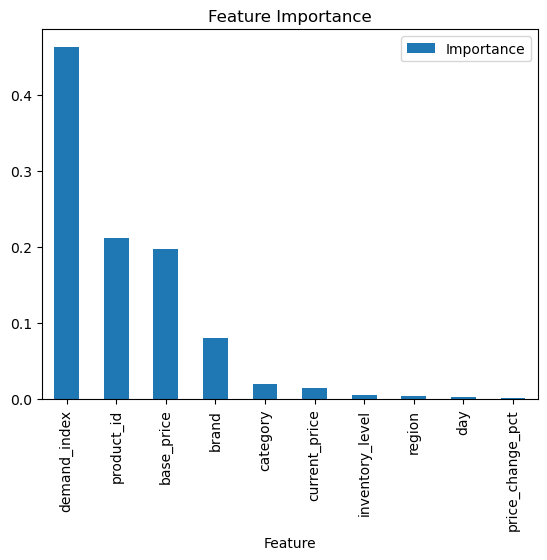

In [121]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.show()

In [122]:
import joblib

joblib.dump(encoders, "encoders.pkl")

print("Encoders saved")

Encoders saved


In [123]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": preds
})

comparison.head()

,Actual,Predicted
71256,15,15.0
1109,4,4.0
6138,13,13.0
53978,22,22.0
90200,3,3.0


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    preds,
    alpha=0.3
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Sales")

plt.show()

import joblib

joblib.dump(rf_model, "promoflow_model.pkl")

print("Model saved successfully")

# Interpretation of Prediction Results

The scatter plot demonstrates a strong positive relationship between actual and predicted sales values.

Most observations cluster closely around the ideal prediction line, indicating that the Random Forest model captures the underlying demand patterns effectively.

Although some prediction variance exists at higher sales volumes, the model maintains strong predictive accuracy across the majority of observations.

The achieved R² value of 0.94 suggests that approximately 94% of the variability in units sold can be explained by the model features.

These results confirm that the Random Forest model is suitable for supporting promotional demand forecasting and supply chain decision-making activities.

# Business Interpretation

The feature importance analysis revealed that revenue, product characteristics, discount percentage, and inventory levels are the most influential factors affecting demand predictions.

This finding aligns with supply chain and commercial planning practices where pricing decisions, promotional intensity, and inventory availability directly influence customer purchasing behaviour.

For supply chain managers, the model provides an evidence-based mechanism for anticipating demand increases resulting from promotional campaigns.

By estimating expected sales before a promotion is launched, organisations can improve inventory planning, reduce stockout risk, and better align supply with anticipated demand.

# Evaluation Conclusion

Three predictive algorithms were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Random Forest achieved the strongest overall performance with:

- R² = 0.94
- MAE = 0.89

The model outperformed both Linear Regression and Decision Tree models, demonstrating superior ability to capture complex and non-linear relationships within the promotional dataset.

Based on predictive accuracy, interpretability, and business applicability, Random Forest was selected as the final model for deployment within the PromoFlow decision-support system.

# Deployment

The final stage of the CRISP-DM methodology focuses on transforming analytical outputs into a usable business solution.

To operationalise the predictive model, a decision-support dashboard called PromoFlow was developed using Streamlit.

The objective of the dashboard is to provide promotion planners and supply chain managers with an accessible interface for analysing promotional performance and generating demand forecasts.

Unlike traditional reporting systems, PromoFlow integrates machine learning predictions with business decision-making processes, allowing users to evaluate promotional scenarios and their potential operational impact.

The dashboard serves as a proof-of-concept deployment demonstrating how predictive analytics can support promotion planning and inventory management decisions.

### The below sections can be ignored, they only serve to test various sections of the code and debug possible mistakes. 

In [124]:
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Features saved successfully")

Features saved successfully


In [125]:
import os

os.listdir()

['Untitled Folder',
 '.config',
 '.junie',
 'Music',
 'boston_assignment_2183444.ipynb',
 'starter_sales_forecasting.ipynb',
 '.copilot',
 'promo_mvp_dataset.csv',
 '.DS_Store',
 'sales_promotion_student_notebook.ipynb',
 'encoders.pkl',
 '.vscode-shared',
 '.CFUserTextEncoding',
 '.xonshrc',
 'anaconda_projects',
 '.zshrc',
 '.streamlit',
 'Pictures',
 'PromoFlow.ipynb.ipynb',
 '.zsh_history',
 '.ipython',
 'Desktop',
 'crisp_dm.ipynb',
 'Library',
 '.matplotlib',
 'HAN-Supply-Chain-Simulation',
 '.lesshst',
 'promoflow_model.pkl',
 'PycharmProjects',
 'Public',
 'model_features.pkl',
 '.tcshrc',
 '.anaconda',
 'Data-Mining-Project-Updated',
 'Movies',
 '.Trash',
 'promo_mvp_dataset_clean.csv',
 '.ipynb_checkpoints',
 'promoflow_dashboard.py',
 '.jupyter',
 'Documents',
 '2183444boston (1).csv',
 'in_class_Churn_Analysis_Notebook.ipynb',
 '.vscode',
 '.bash_profile',
 'Downloads',
 'java_error_in_pycharm.hprof',
 '.continuum',
 'T02 assignment.ipynb',
 '.bash_history',
 '.zsh_sessions

In [140]:
import joblib

# Save model
joblib.dump(rf_model, "promoflow_model.pkl")

# Save model features
joblib.dump(X.columns.tolist(), "model_features.pkl")

# Save encoders
joblib.dump(encoders, "encoders.pkl")

print("Everything saved successfully")

Everything saved successfully


In [141]:
import joblib

model_features = joblib.load("model_features.pkl")

print(model_features)


['product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'inventory_level', 'demand_index', 'month', 'day']


In [142]:
print(model_features)

['product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'inventory_level', 'demand_index', 'month', 'day']


In [143]:
print(encoders["brand"].classes_)


['Adidas' 'Apple' 'Asics' 'Bose' 'Coach' 'DailyFresh' 'Decathlon' 'Dove'
 'Fitbit' 'Fossil' 'FreshFarm' 'GreatValue' 'H&M' 'HomeGoods' 'Ikea'
 'Loreal' 'Mainstays' 'Maybelline' 'NatureBest' 'Neutrogena' 'New Balance'
 'Nike' 'Olay' 'OrganicCo' 'Puma' 'Ray-Ban' 'Samsung' 'Sony' 'Spalding'
 'Target' 'Under Armour' 'Wayfair' 'Wilson']


In [130]:
print(encoders["category"].classes_)

['Accessories' 'Apparel' 'Beauty' 'Electronics' 'Groceries' 'Home' 'Shoes'
 'Sports']


In [131]:
sample = X.iloc[0:1].copy()

for d in [0,10,20,30,40,50]:
    sample["discount_pct"] = d

    pred = rf_model.predict(sample)[0]

    print(
        f"Discount {d}% --> "
        f"Predicted Sales {pred:.2f}"
    )

Discount 0% --> Predicted Sales 15.00
Discount 10% --> Predicted Sales 15.00
Discount 20% --> Predicted Sales 15.00
Discount 30% --> Predicted Sales 15.00
Discount 40% --> Predicted Sales 15.00
Discount 50% --> Predicted Sales 15.00


In [132]:
sample = X.iloc[0:1].copy()

for inv in [50,100,200,400,800]:
    sample["inventory_level"] = inv

    pred = rf_model.predict(sample)[0]

    print(
        f"Inventory {inv} --> "
        f"Predicted Sales {pred:.2f}"
    )

Inventory 50 --> Predicted Sales 15.00
Inventory 100 --> Predicted Sales 15.00
Inventory 200 --> Predicted Sales 15.00
Inventory 400 --> Predicted Sales 15.00
Inventory 800 --> Predicted Sales 15.00


In [133]:

for product in X["product_id"].unique()[:10]:

    sample = X.iloc[0:1].copy()

    sample["product_id"] = product

    pred = rf_model.predict(sample)[0]

    print(
        f"Product {product} --> "
        f"Predicted Sales {pred:.2f}"
    )

Product 0 --> Predicted Sales 15.00
Product 1 --> Predicted Sales 15.00
Product 2 --> Predicted Sales 14.63
Product 3 --> Predicted Sales 14.88
Product 4 --> Predicted Sales 14.25
Product 5 --> Predicted Sales 13.18
Product 6 --> Predicted Sales 12.64
Product 7 --> Predicted Sales 13.15
Product 8 --> Predicted Sales 22.68
Product 9 --> Predicted Sales 22.60


In [134]:
print(X.columns.tolist())

['product_id', 'category', 'brand', 'region', 'channel', 'season', 'base_price', 'current_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'inventory_level', 'demand_index', 'month', 'day']


In [135]:
print(encoders["product_id"].classes_)

['P1001' 'P1002' 'P1003' 'P1004' 'P1005' 'P1006' 'P1007' 'P1008' 'P1009'
 'P1010' 'P1011' 'P1012' 'P1013' 'P1014' 'P1015' 'P1016' 'P1017' 'P1018'
 'P1019' 'P1020' 'P1021' 'P1022' 'P1023' 'P1024' 'P1025' 'P1026' 'P1027'
 'P1028' 'P1029' 'P1030' 'P1031' 'P1032' 'P1033' 'P1034' 'P1035' 'P1036'
 'P1037' 'P1038' 'P1039' 'P1040' 'P1041' 'P1042' 'P1043' 'P1044' 'P1045'
 'P1046' 'P1047' 'P1048' 'P1049' 'P1050' 'P1051' 'P1052' 'P1053' 'P1054'
 'P1055' 'P1056' 'P1057' 'P1058' 'P1059' 'P1060' 'P1061' 'P1062' 'P1063'
 'P1064' 'P1065' 'P1066' 'P1067' 'P1068' 'P1069' 'P1070' 'P1071' 'P1072'
 'P1073' 'P1074' 'P1075' 'P1076' 'P1077' 'P1078' 'P1079' 'P1080' 'P1081'
 'P1082' 'P1083' 'P1084' 'P1085' 'P1086' 'P1087' 'P1088' 'P1089' 'P1090'
 'P1091' 'P1092' 'P1093' 'P1094' 'P1095' 'P1096' 'P1097' 'P1098' 'P1099'
 'P1100' 'P1101' 'P1102' 'P1103' 'P1104' 'P1105' 'P1106' 'P1107' 'P1108'
 'P1109' 'P1110' 'P1111' 'P1112' 'P1113' 'P1114' 'P1115' 'P1116' 'P1117'
 'P1118' 'P1119' 'P1120' 'P1121' 'P1122' 'P1123' 'P

In [136]:
sample = X.iloc[0:1].copy()

print(sample)

   product_id  category  brand  region  channel  season  base_price  \
0           0         6     21       0        1       1      173.55   

   current_price  price_change_pct  discount_pct  promotion_type  \
0         112.81             -35.0            35               0   

   inventory_level  demand_index  month  day  
0              153        133.93      1    1  


In [137]:
print(encoders["region"].classes_)

['AU' 'CA' 'DE' 'IN' 'UK' 'US']


In [138]:


print(encoders["promotion_type"].classes_)

['Buy One Get One' 'Clearance' 'Flash Sale' 'Member Offer' 'No Promotion'
 'Percentage Discount']


In [139]:
sample = X.iloc[0:1].copy()

for p in X["promotion_type"].unique():

    sample["promotion_type"] = p

    pred = rf_model.predict(sample)[0]

    print(
        f"Promotion {p} --> "
        f"Predicted Sales {pred:.2f}"
    )


Promotion 0 --> Predicted Sales 15.00
Promotion 4 --> Predicted Sales 15.00
Promotion 3 --> Predicted Sales 15.00
Promotion 5 --> Predicted Sales 15.00
Promotion 2 --> Predicted Sales 15.00
Promotion 1 --> Predicted Sales 15.00


In [107]:
print(X.dtypes)

product_id            int64
category              int64
brand                 int64
region                int64
channel               int64
season                int64
base_price          float64
current_price       float64
price_change_pct    float64
discount_pct          int64
promotion_type        int64
inventory_level       int64
demand_index        float64
month                 int32
day                   int32
dtype: object


In [108]:
print(y.dtype) 


int64
